#Setup (run first, once)

In [1]:
# Mount Drive - only needed for saving final results, not for training data
from google.colab import drive
drive.mount('/content/drive')

import os
os.makedirs('/content/drive/MyDrive/ppe-project/models', exist_ok=True)

Mounted at /content/drive


In [2]:
# Download dataset directly to local Colab storage (fast, bypasses Drive I/O)
os.makedirs('/content/local_dataset', exist_ok=True)
%cd /content/local_dataset

!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="RYjUPdnRCS5m2CaZPWHl")
project = rf.workspace("roboflow-universe-projects").project("construction-site-safety")
version = project.version(27)
dataset = version.download("yolov8")

print(dataset.location)  # confirm the actual local path

/content/local_dataset
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 285.0/285.0 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 22.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 87.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 58.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 1.4 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 5.0.0.93
    Uninstalling opencv-python-headless-5.0.0.93:
      Successfully uninstalled opencv-python-headless-5.0.0.93
  Attempting uninstall: typer
    Found existing installation: typer 0.26.8
    Uninstalling typer-0.26.8:
      Successfully uninstalled typer-0.26.8
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Construction-Site-Safety-27 in yolov8:: 100%|██████████| 5610/5610 [00:00<00:00, 6710.07it/s]

/content/local_dataset/Construction-Site-Safety-27


In [3]:
# Reload config
import yaml
with open(f'{dataset.location}/data.yaml', 'r') as f:
    config = yaml.safe_load(f)

names = config['names']
print(names)

['Hardhat', 'Mask', 'NO-Hardhat', 'NO-Mask', 'NO-Safety Vest', 'Person', 'Safety Cone', 'Safety Vest', 'machinery', 'vehicle']


#Stage 1: Classical ML baseline

In [4]:
import cv2
import numpy as np

def extract_crop_features(img_path, bbox, img_w, img_h):
    x, y, bw, bh = bbox
    x1, y1 = int((x-bw/2)*img_w), int((y-bh/2)*img_h)
    x2, y2 = int((x+bw/2)*img_w), int((y+bh/2)*img_h)
    img = cv2.imread(img_path)
    if img is None:
        return None
    crop = img[max(0,y1):y2, max(0,x1):x2]
    if crop.size == 0:
        return None
    crop = cv2.resize(crop, (32,32))
    mean_color = crop.mean(axis=(0,1))
    hist = cv2.calcHist([crop], [0,1,2], None, [4,4,4], [0,256,0,256,0,256]).flatten()
    return np.concatenate([mean_color, hist])

In [5]:
from tqdm import tqdm

hardhat_id = names.index('Hardhat')
no_hardhat_id = names.index('NO-Hardhat')

X, y = [], []
img_dir = f'{dataset.location}/train/images'
label_dir = f'{dataset.location}/train/labels'

label_files = os.listdir(label_dir)[:800]  # kept small for speed

for label_file in tqdm(label_files):
    img_file = label_file.rsplit('.',1)[0] + '.jpg'
    img_path = f'{img_dir}/{img_file}'
    if not os.path.exists(img_path):
        continue
    img = cv2.imread(img_path)
    if img is None:
        continue
    h, w = img.shape[:2]
    with open(f'{label_dir}/{label_file}') as f:
        for line in f:
            cls, x, y_, bw, bh = map(float, line.split())
            cls = int(cls)
            if cls in [hardhat_id, no_hardhat_id]:
                feat = extract_crop_features(img_path, (x,y_,bw,bh), w, h)
                if feat is not None:
                    X.append(feat)
                    y.append(1 if cls == hardhat_id else 0)

X, y = np.array(X), np.array(y)
print(X.shape, y.shape)

100%|██████████| 800/800 [00:07<00:00, 109.70it/s]

(1917, 67) (1917,)


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred, target_names=['Violation','Compliant']))

              precision    recall  f1-score   support

   Violation       0.72      0.64      0.68       151
   Compliant       0.78      0.84      0.81       233

    accuracy                           0.76       384
   macro avg       0.75      0.74      0.74       384
weighted avg       0.76      0.76      0.76       384



#Stage 2: Weights & Biases setup

In [7]:
#Weights and Biases
!pip install wandb -q
import wandb
wandb.login()  # paste your API key from wandb.ai/authorize when prompted

invalid escape sequence '\/'
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results


wandb: Enter your choice: 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.


wandb: Paste your API key and hit enter: ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: innovativeskipper (innovativeskipper-utm) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [8]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

True
Tesla T4


#Stage 3: YOLOv8 fine-tuning (now fully local — should be much faster)

In [9]:
!pip install ultralytics -q

from ultralytics import YOLO

model = YOLO('yolov8n.pt')

results = model.train(
    data=f'{dataset.location}/data.yaml',
    epochs=40,
    imgsz=640,
    batch=16,
    project='ppe-detection',
    name='yolov8n-ppe',
    device=0
)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 36.6 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.114 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/local_dataset/Construction-Site-Safety-27/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, d

#Stage 4: Evaluate and save

In [10]:
metrics = model.val()
print("mAP50-95:", metrics.box.map)
print("mAP50:", metrics.box.map50)
print("Per-class mAP50:", metrics.box.maps)

Ultralytics 8.4.114 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,007,598 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1457.2±465.0 MB/s, size: 56.0 KB)
val: Scanning /content/local_dataset/Construction-Site-Safety-27/valid/labels.cache... 114 images, 10 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 114/114 28.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 1.0it/s 7.8s
                   all        114        697      0.882      0.698      0.766      0.456
               Hardhat         42         79      0.916      0.759      0.836      0.496
                  Mask         19         21      0.953       0.81      0.896      0.626
            NO-Hardhat         37         69      0.876      0.551      0.634      0.336
               NO-Mask         44         74       0.89      0.546      0.606      0.272
        NO-Safe


image 1/1 /content/local_dataset/Construction-Site-Safety-27/test/images/youtube-152_jpg.rf.9147878e3ddda845e58f7d9c041f1338.jpg: 640x640 3 Persons, 5 machinerys, 5 vehicles, 12.3ms
Speed: 2.7ms preprocess, 12.3ms inference, 2.0ms postprocess per image at shape (1, 3, 640, 640)


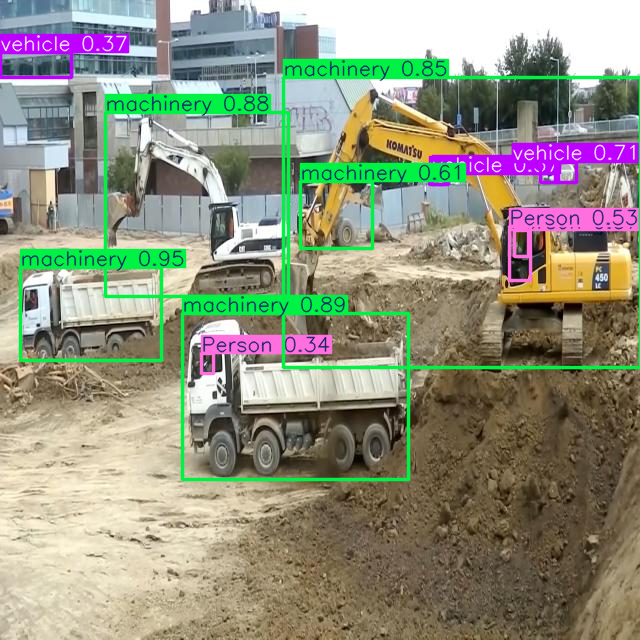

In [11]:
# Quick visual sanity check
import os
test_img_dir = f'{dataset.location}/test/images'
sample_img = os.path.join(test_img_dir, os.listdir(test_img_dir)[0])

results = model(sample_img)
results[0].show()

In [13]:
import shutil
shutil.copy(
    '/content/local_dataset/runs/detect/ppe-detection/yolov8n-ppe/weights/best.pt',
    '/content/drive/MyDrive/ppe-project/models/best.pt'
)
print("Saved to Drive.")

Saved to Drive.
